# **Inisialisasi**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv('/content/clothout.csv')
df.head(5)

,weight,age,height,size,bmi
0,62,28.0,172.72,5,20.782914
1,59,36.0,167.64,4,20.994073
2,51,33.0,160.02,1,19.916895
3,53,32.0,165.10,2,19.443826
4,54,21.0,167.64,1,19.214914


In [ ]:
df2 = pd.read_csv('/content/cloth.csv')
df2.head(5)

FileNotFoundError: ignored

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104193 entries, 0 to 104192
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   age     104193 non-null  float64
 1   height  104193 non-null  float64
 2   weight  104193 non-null  float64
 3   size    104193 non-null  int64  
 4   bmi     104193 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 4.0 MB


In [ ]:
y = df["size"]
X = df.drop(["size"],axis=1)

# **Decission Pred**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X1 = X
Y1 = y
best_random_state = None
best_accuracy = 0

# Uji berbagai nilai random_state
for random_state in range(1000):
    X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.2, random_state=random_state)
    dt = DecisionTreeClassifier(random_state=0)
    dt.fit(X1_train, Y1_train)
    Y1_pred = dt.predict(X1_test)
    accuracy = accuracy_score(Y1_test, Y1_pred) * 100

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_random_state = random_state

print(f"Best Random State: {best_random_state}")
print(f"Best Accuracy: {best_accuracy}%")

Best Random State: 990
Best Accuracy: 99.99582411157974%


# **Decission Test**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Bagi dataset menjadi data latih dan data uji
X4 = X
y4 = y
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=0)

dt = DecisionTreeClassifier()
dt.fit(X4_train, y4_train)

dt_accuracy = dt.score(X4_test, y4_test)
print("Accuracy:", dt_accuracy*100)

Accuracy: 99.97076878105817


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y4_pred = dt.predict(X4_test)
print('\nconfusion matrix')
cm4 = confusion_matrix(y4_test, y4_pred)
print(cm4)
print('\naccuracy')
print(accuracy_score(y4_test, y4_pred)*100)
print('\nclassification report')
print(classification_report(y4_test, y4_pred))


confusion matrix
[[2007    0    2    0    0    0    0]
 [   0 4429    0    0    0    0    2]
 [   0    0 5918    0    0    0    1]
 [   0    0    0 3465    0    0    0]
 [   0    0    0    0 3847    0    0]
 [   0    0    0    0    0   13    2]
 [   0    0    0    0    0    0 4261]]

accuracy
99.97076878105817

classification report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2009
           2       1.00      1.00      1.00      4431
           3       1.00      1.00      1.00      5919
           4       1.00      1.00      1.00      3465
           5       1.00      1.00      1.00      3847
           6       1.00      0.87      0.93        15
           7       1.00      1.00      1.00      4261

    accuracy                           1.00     23947
   macro avg       1.00      0.98      0.99     23947
weighted avg       1.00      1.00      1.00     23947



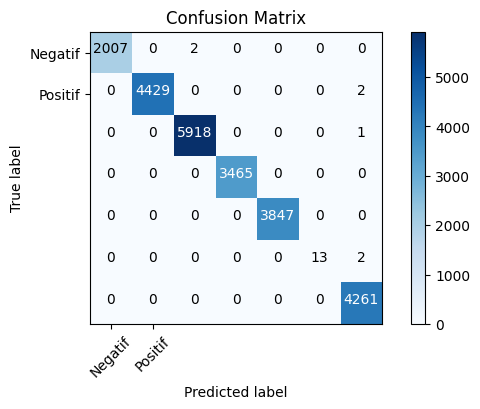

In [ ]:
import itertools
confusion_matrix = cm4

# Definisikan label kelas
class_names = ['Negatif', 'Positif']

# Plot confusion matrix
plt.figure(figsize=(6, 4))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

# Tambahkan label pada sumbu x dan y
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Tampilkan nilai di dalam sel
thresh = confusion_matrix.max() / 2.
for i, j in itertools.product(range(confusion_matrix.shape[0]), range(confusion_matrix.shape[1])):
    plt.text(j, i, format(confusion_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if confusion_matrix[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

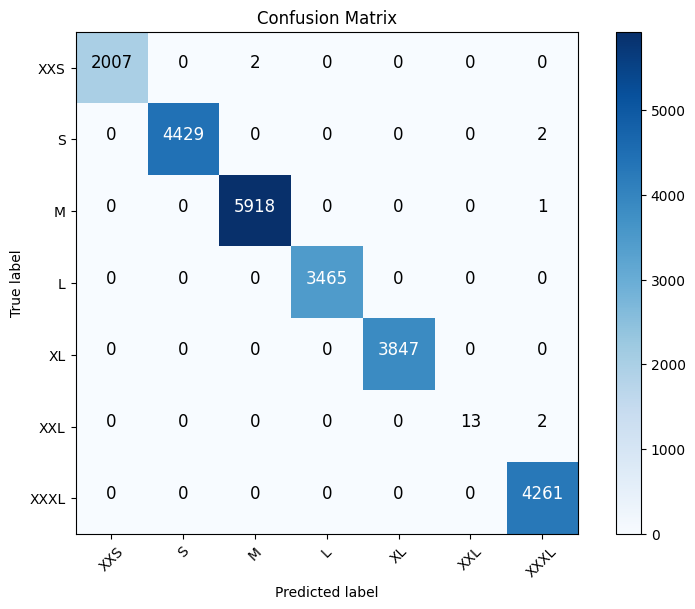

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Definisikan label kelas sesuai dengan rentang ukuran 1-7
class_names = ['XXS', 'S', 'M', 'L', 'XL', 'XXL', 'XXXL']

# Contoh matriks konfusi (ganti dengan matriks konfusi yang sesuai)
confusion_matrix = cm4

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

# Tambahkan label pada sumbu x dan y
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Tampilkan nilai di dalam sel dengan font yang lebih besar
thresh = confusion_matrix.max() / 2.
for i, j in itertools.product(range(confusion_matrix.shape[0]), range(confusion_matrix.shape[1])):
    plt.text(j, i, format(confusion_matrix[i, j], 'd'),
             fontsize=12,  # Ubah ukuran font sesuai kebutuhan
             horizontalalignment="center",
             color="white" if confusion_matrix[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



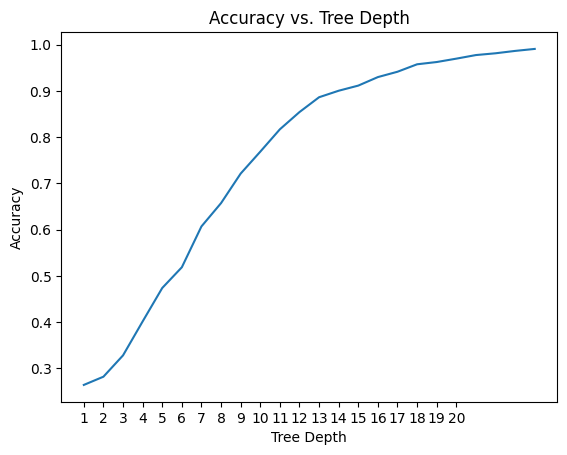

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Inisialisasi list untuk menyimpan akurasi pada berbagai kedalaman pohon
depths = list(range(1, 25))  # Misalnya, coba kedalaman dari 1 hingga 20
accuracies = []

# Melatih model Decision Tree pada berbagai kedalaman pohon
for depth in depths:
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=66)
    dt_model.fit(X4_train, y4_train)
    accuracy = dt_model.score(X4_test, y4_test)
    accuracies.append(accuracy)

# Menampilkan grafik perubahan akurasi dengan kedalaman pohon
plt.plot(depths, accuracies)
plt.ylabel('Accuracy')
plt.xlabel('Tree Depth')
plt.title('Accuracy vs. Tree Depth')
plt.xticks(np.arange(1, 21, 1))  # Label sumbu x dari 1 hingga 20
plt.show()

# **RandomForest Best**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X1 = X
Y1 = y
best_random_state = None
best_accuracy = 0

# Uji berbagai nilai random_state, n_estimators, dan max_depth
for random_state in range(1000):
    for n_estimators in [10, 50, 100, 200]:  # Ganti nilai n_estimators sesuai kebutuhan
        for max_depth in [None, 10, 20, 30]:  # Ganti nilai max_depth sesuai kebutuhan
            X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.2, random_state=random_state)

            rf = RandomForestClassifier(random_state=random_state, n_estimators=n_estimators, max_depth=max_depth)

            rf.fit(X1_train, Y1_train)
            Y1_pred = rf.predict(X1_test)
            accuracy = accuracy_score(Y1_test, Y1_pred) * 100

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_random_state = random_state
                best_n_estimators = n_estimators
                best_max_depth = max_depth

print(f"Best Random State: {best_random_state}")
print(f"Best n_estimators: {best_n_estimators}")
print(f"Best max_depth: {best_max_depth}")
print(f"Best Accuracy: {best_accuracy}%")


# **RandomForest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Bagi dataset menjadi data latih dan data uji
X9 = X
y9 = y
X9_train, X9_test, y9_train, y9_test = train_test_split(X9, y9, test_size=0.2, random_state=10)

# Inisialisasi model Random Forest dengan parameter tertentu
random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=0)  # Ganti parameter sesuai kebutuhan

# Latih model
random_forest.fit(X9_train, y9_train)

# Evaluasi model
rf_accuracy = random_forest.score(X9_test, y9_test)
print("Random Forest Accuracy:", rf_accuracy * 100)


Random Forest Accuracy: 82.81621915062429


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Melakukan prediksi dengan model Random Forest
y9_pred_rf = random_forest.predict(X9_test)

# Matriks kebingungan
cm4_rf = confusion_matrix(y9_test, y9_pred_rf)
print('\nConfusion Matrix Random Forest:')
print(cm4_rf)

# Akurasi
accuracy_rf = accuracy_score(y9_test, y9_pred_rf) * 100
print('\nAccuracy Random Forest:', accuracy_rf)

# Laporan Klasifikasi
classification_report_rf = classification_report(y9_test, y9_pred_rf)
print('\nClassification Report Random Forest:')
print(classification_report_rf)



Confusion Matrix Random Forest:
[[1301    0  424    0    8    0  276]
 [   0 3504  810   10    7    0  100]
 [   5    0 5764    0    4    0  146]
 [  10   11  704 2611   39    0   90]
 [   0    0  646    0 3034    0  167]
 [   0    0    4    1    0    2    8]
 [   2    0  525    0   13    0 3721]]

Accuracy Random Forest: 83.25468743475174

Classification Report Random Forest:
              precision    recall  f1-score   support

           1       0.99      0.65      0.78      2009
           2       1.00      0.79      0.88      4431
           3       0.65      0.97      0.78      5919
           4       1.00      0.75      0.86      3465
           5       0.98      0.79      0.87      3847
           6       1.00      0.13      0.24        15
           7       0.83      0.87      0.85      4261

    accuracy                           0.83     23947
   macro avg       0.92      0.71      0.75     23947
weighted avg       0.88      0.83      0.84     23947



# **KNN Pred**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X1 = X  # Gantilah X dengan dataset Anda
Y1 = y  # Gantilah y dengan target Anda

best_random_state = None
best_accuracy = 0

# Uji berbagai nilai random_state
for random_state in range(1000):
    X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.2, random_state=random_state)
    knn = KNeighborsClassifier(n_neighbors=5)  # Gantilah dengan nilai k yang sesuai
    knn.fit(X1_train, Y1_train)
    Y1_pred = knn.predict(X1_test)
    accuracy = accuracy_score(Y1_test, Y1_pred) * 100

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_random_state = random_state

print(f"Best Random State: {best_random_state}")
print(f"Best Accuracy: {best_accuracy}%")


Best Random State: 820
Best Accuracy: 87.9650895728066%


# **KNN**

In [ ]:
  from sklearn.neighbors import KNeighborsClassifier
  from sklearn.metrics import confusion_matrix, accuracy_score

  X2 = X
  y2 = y
  X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.20, random_state = 820)
  classifier1 = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
  classifier1.fit(X2_train, y2_train)
  y2_pred = classifier1.predict(X2_test)
  cm1 = confusion_matrix(y2_test, y2_pred)
  print(cm1)
  accuracy_score(y2_test, y2_pred)*100

[[1912    2   13    2    8    0   10]
 [   5 4361    7    3    2    0   13]
 [   3    2 5980    4    2    0    3]
 [  10   10    2 3419    6    0    5]
 [   4   16    8    4 3849    0   14]
 [   0    1    3    1    1    1   10]
 [   6   12   20   16   19    0 4178]]


98.96855556019544

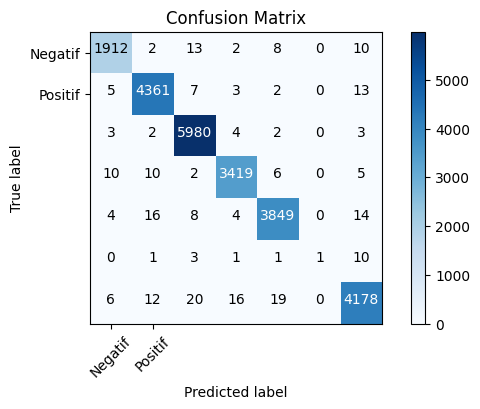

In [ ]:
import itertools
confusion_matrix = cm1

# Definisikan label kelas
class_names = ['Negatif', 'Positif']

# Plot confusion matrix
plt.figure(figsize=(6, 4))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

# Tambahkan label pada sumbu x dan y
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Tampilkan nilai di dalam sel
thresh = confusion_matrix.max() / 2.
for i, j in itertools.product(range(confusion_matrix.shape[0]), range(confusion_matrix.shape[1])):
    plt.text(j, i, format(confusion_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if confusion_matrix[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

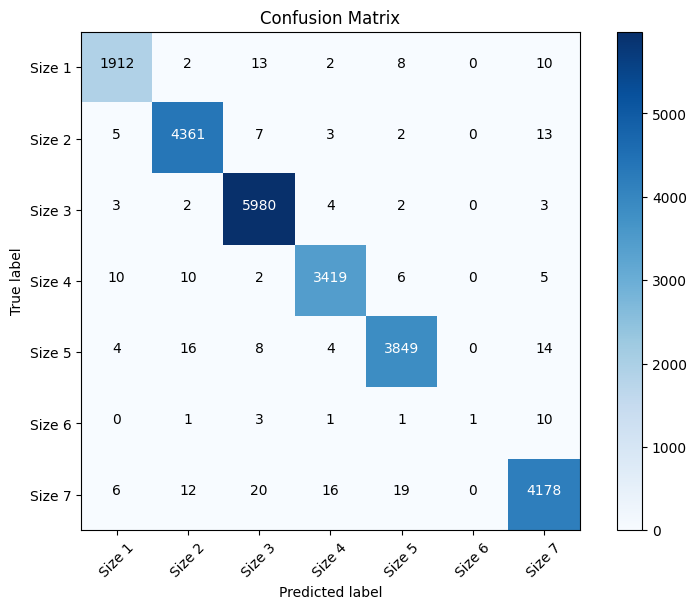

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Definisikan label kelas sesuai dengan rentang ukuran 1-7
class_names = ['Size 1', 'Size 2', 'Size 3', 'Size 4', 'Size 5', 'Size 6', 'Size 7']

# Contoh matriks konfusi (ganti dengan matriks konfusi yang sesuai)
confusion_matrix = cm1

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

# Tambahkan label pada sumbu x dan y
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Tampilkan nilai di dalam sel
thresh = confusion_matrix.max() / 2.
for i, j in itertools.product(range(confusion_matrix.shape[0]), range(confusion_matrix.shape[1])):
    plt.text(j, i, format(confusion_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if confusion_matrix[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


# **BAYES**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Bagi dataset menjadi data latih dan data uji (gunakan dataset yang sesuai)
X3 = X
y3 = y
X3_train, X3_test, y3_train, y3_test = train_test_split(X, y, test_size=0.2, random_state=990)

# Inisialisasi model Naive Bayes
naive_bayes = MultinomialNB()

# Latih model menggunakan data latih
naive_bayes.fit(X3_train, y3_train)

# Evaluasi model
nb_accuracy = naive_bayes.score(X3_test, y3_test)
print("Naive Bayes Accuracy:", nb_accuracy * 100)

y_pred = naive_bayes.predict(X3_test)

# Confusion Matrix
cm = confusion_matrix(y3_test, y_pred)
print('\nConfusion Matrix:')
print(cm)

# Accuracy
print('\nAccuracy:')
print(accuracy_score(y3_test, y_pred) * 100)

# Classification Report
print('\nClassification Report:')
print(classification_report(y3_test, y_pred))


ValueError: ignored

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Bagi dataset menjadi data latih dan data uji
X = X
y = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi model Gaussian Naive Bayes
gaussian_naive_bayes = GaussianNB()

# Latih model menggunakan data latih
gaussian_naive_bayes.fit(X_train, y_train)

# Evaluasi model
nb_accuracy = gaussian_naive_bayes.score(X_test, y_test)
print("Gaussian Naive Bayes Accuracy:", nb_accuracy * 100)

y_pred = gaussian_naive_bayes.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)

# Accuracy
print('\nAccuracy:')
print(accuracy_score(y_test, y_pred) * 100)

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Gaussian Naive Bayes Accuracy: 60.35846923946391

Confusion Matrix:
[[   0  906   29    0    1    0]
 [   0 2870  298    0    0    0]
 [   0  507  794    0    0    5]
 [   0  181  411    3    0   14]
 [   0    0    0    0    0    0]
 [   0   35   67    1    0   71]]

Accuracy:
60.35846923946391

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       936
           2       0.64      0.91      0.75      3168
           4       0.50      0.61      0.55      1306
           5       0.75      0.00      0.01       609
           6       0.00      0.00      0.00         0
           7       0.79      0.41      0.54       174

    accuracy                           0.60      6193
   macro avg       0.45      0.32      0.31      6193
weighted avg       0.53      0.60      0.51      6193



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.